In [1]:
import os
import time
import joblib
import numpy as np

# Define file paths to saved artifacts from Phase 3
PROCESSED_DIR = os.path.join("..", "data", "processed")

train_features_path = os.path.join(PROCESSED_DIR, "X_train_tfidf.joblib")
test_features_path  = os.path.join(PROCESSED_DIR, "X_test_tfidf.joblib")
train_labels_path   = os.path.join(PROCESSED_DIR, "y_train.joblib")
test_labels_path    = os.path.join(PROCESSED_DIR, "y_test.joblib")

# Load sparse matrices and labels
print("Loading feature matrices and target labels...")
X_train_tfidf = joblib.load(train_features_path)
X_test_tfidf  = joblib.load(test_features_path)
y_train       = joblib.load(train_labels_path)
y_test        = joblib.load(test_labels_path)

print(f"✅ X_train_tfidf loaded : {X_train_tfidf.shape[0]:,} samples × {X_train_tfidf.shape[1]:,} features")
print(f"✅ X_test_tfidf  loaded : {X_test_tfidf.shape[0]:,} samples × {X_test_tfidf.shape[1]:,} features")
print(f"✅ y_train length        : {len(y_train):,}")
print(f"✅ y_test length         : {len(y_test):,}")

Loading feature matrices and target labels...
✅ X_train_tfidf loaded : 40,000 samples × 10,000 features
✅ X_test_tfidf  loaded : 10,000 samples × 10,000 features
✅ y_train length        : 40,000
✅ y_test length         : 10,000


In [2]:
from sklearn.linear_model import LogisticRegression

# 1. Instantiate Logistic Regression model with fixed seed for reproducibility
RANDOM_STATE = 42

baseline_model = LogisticRegression(
    solver='liblinear',     # High-efficiency coordinate descent solver for sparse data
    C=1.0,                  # Standard inverse regularization strength
    random_state=RANDOM_STATE,
    max_iter=1000           # Guarantee convergence
)

print("Logistic Regression Classifier initialized:")
print(f"  • Solver       : {baseline_model.solver}")
print(f"  • C (Reg Cost) : {baseline_model.C}")
print(f"  • Random State : {baseline_model.random_state}")

Logistic Regression Classifier initialized:
  • Solver       : liblinear
  • C (Reg Cost) : 1.0
  • Random State : 42


In [3]:
# Measure model training duration
start_time = time.time()

# Fit the classifier strictly on the training set
print("Fitting Logistic Regression model on X_train_tfidf...")
baseline_model.fit(X_train_tfidf, y_train)

elapsed_time = time.time() - start_time
print(f"✅ Baseline model training completed in {elapsed_time:.3f} seconds.")

Fitting Logistic Regression model on X_train_tfidf...
✅ Baseline model training completed in 1.040 seconds.


In [5]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# 1. Generate predictions on held-out test matrix
y_pred = baseline_model.predict(X_test_tfidf)
y_prob = baseline_model.predict_proba(X_test_tfidf)[:, 1]

# 2. Compute core classification metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

metrics_baseline = {
    "model": "Logistic Regression (Baseline)",
    "accuracy": round(float(accuracy), 4),
    "precision": round(float(precision), 4),
    "recall": round(float(recall), 4),
    "f1_score": round(float(f1), 4)
}

# 3. Print metric overview
print("==================================================")
print("     LOGISTIC REGRESSION BASELINE PERFORMANCE     ")
print("==================================================")
for metric, val in metrics_baseline.items():
    if metric != "model":
        print(f"  • {metric.capitalize():<12}: {val:.4f} ({val*100:.2f}%)")
print("==================================================\n")

print("--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred, target_names=["Negative (0)", "Positive (1)"]))

     LOGISTIC REGRESSION BASELINE PERFORMANCE     
  • Accuracy    : 0.9010 (90.10%)
  • Precision   : 0.8939 (89.39%)
  • Recall      : 0.9100 (91.00%)
  • F1_score    : 0.9019 (90.19%)

--- Detailed Classification Report ---
              precision    recall  f1-score   support

Negative (0)       0.91      0.89      0.90      5000
Positive (1)       0.89      0.91      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



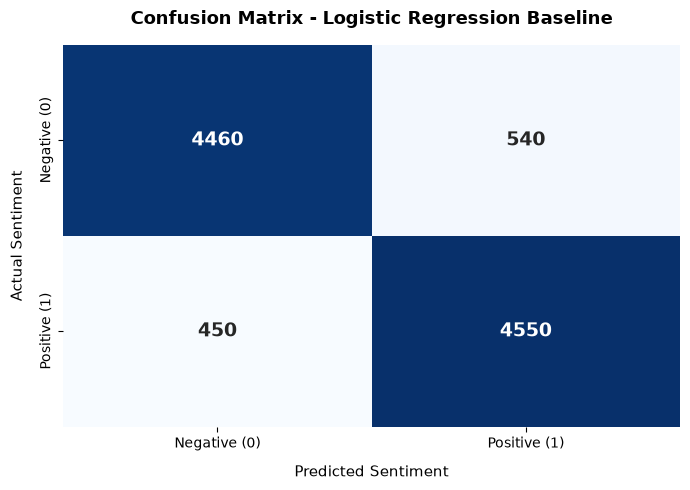

✅ Confusion matrix plot saved to: ..\reports\figures\baseline_confusion_matrix.png


In [6]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Configure plot figure
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=False,
    xticklabels=['Negative (0)', 'Positive (1)'],
    yticklabels=['Negative (0)', 'Positive (1)'],
    annot_kws={"size": 14, "weight": "bold"}
)

# Set descriptive axes labels and titles
plt.title('Confusion Matrix - Logistic Regression Baseline', fontsize=13, pad=15, weight='bold')
plt.xlabel('Predicted Sentiment', fontsize=11, labelpad=10)
plt.ylabel('Actual Sentiment', fontsize=11, labelpad=10)
plt.tight_layout()

# Save image for README / Phase 10 documentation
os.makedirs("../reports/figures", exist_ok=True)
cm_fig_path = os.path.join("..", "reports", "figures", "baseline_confusion_matrix.png")
plt.savefig(cm_fig_path, dpi=300)
plt.show()

print(f"✅ Confusion matrix plot saved to: {cm_fig_path}")

In [7]:
# Save baseline metrics dictionary to JSON
REPORTS_DIR = os.path.join("..", "reports")
os.makedirs(REPORTS_DIR, exist_ok=True)

metrics_json_path = os.path.join(REPORTS_DIR, "baseline_metrics.json")

with open(metrics_json_path, "w") as f:
    json.dump(metrics_baseline, f, indent=4)

print(f"✅ Baseline metrics saved to: {metrics_json_path}")

✅ Baseline metrics saved to: ..\reports\baseline_metrics.json


In [10]:
import os
import joblib

# Ensure target models directory exists
MODELS_DIR = os.path.join("..", "models")
os.makedirs(MODELS_DIR, exist_ok=True)

# Define output paths for model and vectorizer
model_path = os.path.join(MODELS_DIR, "logreg_model.joblib")
vectorizer_path = os.path.join(MODELS_DIR, "tfidf_vectorizer.joblib")

# 1. Serialize trained Logistic Regression model
joblib.dump(baseline_model, model_path)
print(f"✅ Baseline model saved to      : {model_path}")

# 2. Load vectorizer from Phase 3 if not already in memory
if 'vectorizer' not in locals():
    print("Loading vectorizer saved from Phase 3...")
    vectorizer = joblib.load(vectorizer_path)

# 3. Confirm vectorizer artifact exists on disk
print(f"✅ Fitted vectorizer confirmed at : {vectorizer_path}")

✅ Baseline model saved to      : ..\models\logreg_model.joblib
Loading vectorizer saved from Phase 3...
✅ Fitted vectorizer confirmed at : ..\models\tfidf_vectorizer.joblib


In [11]:
import sys
sys.path.append("..")
from src.preprocessing import process_and_lemmatize_review

# 1. Load artifacts back from disk to simulate API runtime environment
loaded_model = joblib.load(model_path)
loaded_vectorizer = joblib.load(vectorizer_path)

# 2. Define test raw text inputs
sample_raw_reviews = [
    "An absolute masterpiece! The acting was incredible and the story kept me hooked until the end.",
    "Boring, slow, and completely predictable. Waste of two hours of my life."
]

# 3. Process, transform, and predict
print("--- Artifact Loading & Inference Verification ---")
for text in sample_raw_reviews:
    cleaned = process_and_lemmatize_review(text)
    vectorized = loaded_vectorizer.transform([cleaned])
    
    pred_label = loaded_model.predict(vectorized)[0]
    pred_proba = loaded_model.predict_proba(vectorized)[0]
    
    sentiment_str = "POSITIVE" if pred_label == 1 else "NEGATIVE"
    confidence = pred_proba[pred_label] * 100
    
    print(f"\nRaw Input  : '{text}'")
    print(f"Cleaned    : '{cleaned}'")
    print(f"Prediction : {sentiment_str} (Confidence: {confidence:.2f}%)")

ModuleNotFoundError: No module named 'src.preprocessing'